<a href="https://colab.research.google.com/github/iambast/plant-disease-detection/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Plant Disease Detection with Visual Explainability
## Phase 1: Exploratory Data Analysis (EDA)

#**Dataset:** PlantVillage (Kaggle)
#**Objective:** Explore dataset structure, class distribution, and sample images before preprocessing.

SyntaxError: invalid syntax (3847997723.py, line 4)

In [15]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
import os
from getpass import getpass
from google.colab import userdata
userdata.get('KAGGLE_API_TOKEN')

os.environ['KAGGLE_API_TOKEN']

!pip install kaggle

In [8]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d plant_data

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
plantdisease.zip: Skipping, found more recently modified local copy (use --force to force download)
replace plant_data/PlantVillage/Pepper__bell___Bacterial_spot/0022d6b7-d47c-4ee2-ae9a-392a53f48647___JR_B.Spot 8964.JPG? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [9]:
import os
for root, dirs, files in os.walk('plant_data'):
    print(root, '->', dirs[:5])  # show first 5 subfolders at each level
    if root.count(os.sep) > 2:  # limit depth printed
        break

plant_data -> ['plantvillage', 'PlantVillage']
plant_data/plantvillage -> ['PlantVillage']
plant_data/plantvillage/PlantVillage -> ['Tomato_Early_blight', 'Tomato__Target_Spot', 'Potato___healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Pepper__bell___Bacterial_spot']
plant_data/plantvillage/PlantVillage/Tomato_Early_blight -> []


In [10]:
import os

data_dir = 'plant_data/plantvillage/PlantVillage'
classes = os.listdir(data_dir)
print(f"Number of classes: {len(classes)}")

Number of classes: 15


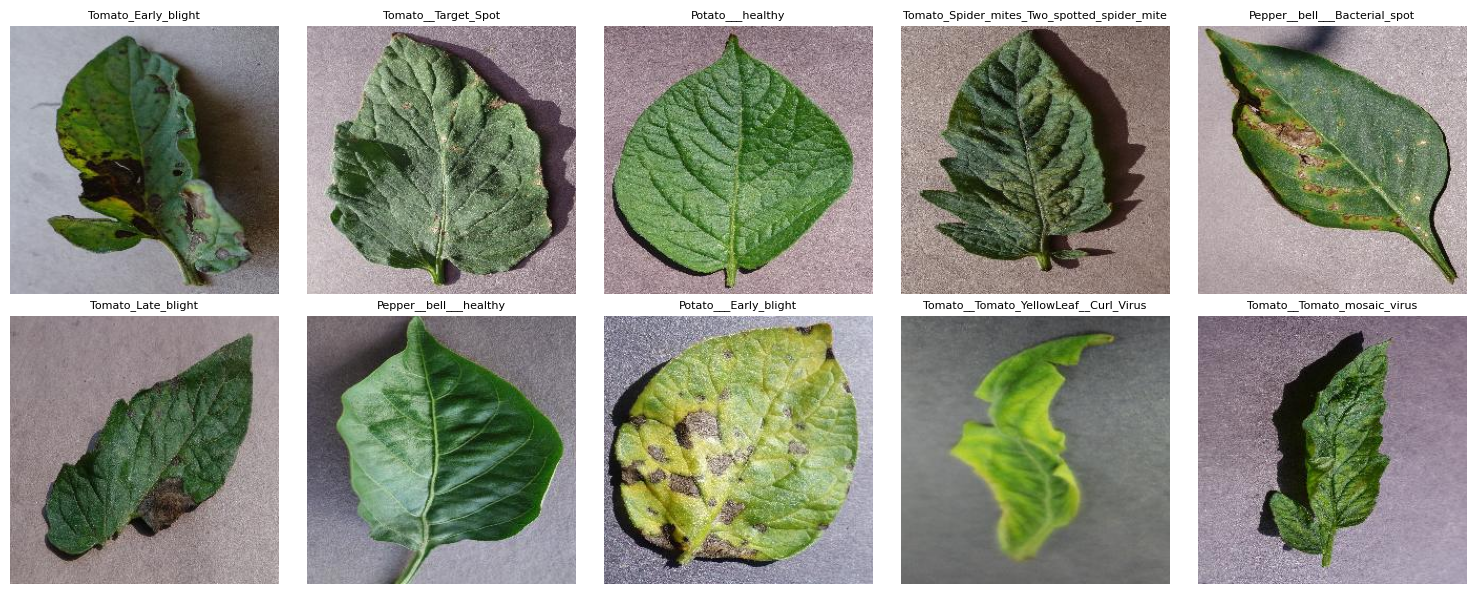

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_classes = classes[:10]

for ax, cls in zip(axes.flatten(), sample_classes):
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

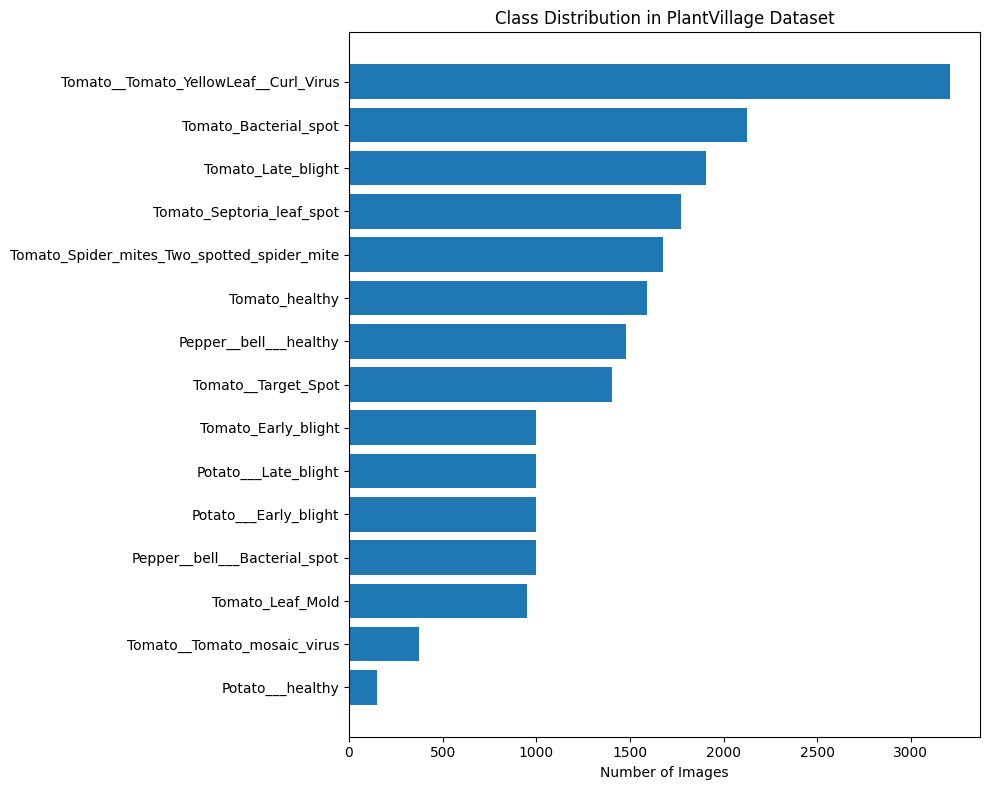

In [12]:
import pandas as pd

class_counts = {c: len(os.listdir(os.path.join(data_dir, c))) for c in classes}
df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count']).sort_values('Count')

plt.figure(figsize=(10, 8))
plt.barh(df['Class'], df['Count'])
plt.xlabel('Number of Images')
plt.title('Class Distribution in PlantVillage Dataset')
plt.tight_layout()
plt.show()